# 2. Cost-sensitive baselines

**Question: what do the trivial policies cost, and where should the threshold sit?**

Two policies need no model at all: inspect nothing, or inspect everything. They bracket
the problem. Any model that costs more than the cheaper of the two has negative value,
and that is a surprisingly easy bar to fail once the 50:1 cost ratio is taken
seriously.

This notebook also derives the threshold implied by the cost ratio, which is the number
that makes `0.5` indefensible.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


## The two policies that need no model

`always_negative` never inspects, so it pays 500 for every failure it misses.
`always_positive` inspects every truck, so it pays 10 for each healthy one.

In [2]:
from scania_aps.costs import maintenance_cost
from scania_aps.plotting import emphasis_bars

y_test = test.y.to_numpy()

policies = {
    "inspect nothing": np.zeros_like(y_test),
    "inspect everything": np.ones_like(y_test),
}
rows = []
for name, prediction in policies.items():
    result = maintenance_cost(y_test, prediction)
    rows.append(
        {
            "policy": name,
            "false_positives": result.false_positives,
            "false_negatives": result.false_negatives,
            "total_cost": result.total_cost,
            "cost_per_truck": result.cost_per_observation,
        }
    )

baselines = pd.DataFrame(rows).set_index("policy")
baselines

,false_positives,false_negatives,total_cost,cost_per_truck
policy,,,,
inspect nothing,0,375,187500.0,11.718750
inspect everything,15625,0,156250.0,9.765625


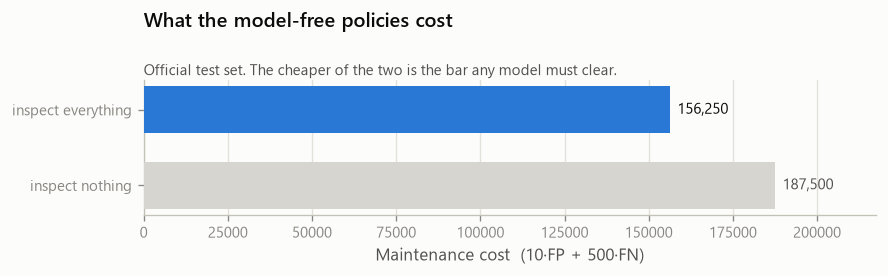

In [3]:
fig, ax = emphasis_bars(
    list(baselines.index),
    [float(v) for v in baselines["total_cost"].to_numpy()],
    title="What the model-free policies cost",
    subtitle="Official test set. The cheaper of the two is the bar any model must clear.",
    xlabel="Maintenance cost  (10·FP + 500·FN)",
)

Inspecting everything is far cheaper than inspecting nothing — the 50:1 ratio means
even a policy with no discrimination at all does better by erring towards inspection.
That asymmetry drives everything that follows.

## Where should the threshold sit?

For a **calibrated** probability, the expected cost of inspecting is `10·(1−p)` and the
expected cost of not inspecting is `500·p`. Inspecting is worth it as soon as

```
500·p > 10·(1 − p)   ⇒   p > 10 / (10 + 500) ≈ 0.0196
```

So the decision boundary implied by the costs is **0.0196**, not 0.5. A model thresholded
at 0.5 is implicitly asserting that a false negative and a false positive cost the same
— which for this fleet is wrong by a factor of fifty.

In [4]:
from scania_aps.costs import FALSE_NEGATIVE_COST, FALSE_POSITIVE_COST, bayes_threshold

tau = bayes_threshold()
print(f"false positive cost: {FALSE_POSITIVE_COST:.0f}")
print(f"false negative cost: {FALSE_NEGATIVE_COST:.0f}")
print(f"Bayes threshold    : {tau:.6f}")
print()
print(f"That is {0.5 / tau:.0f}x lower than the conventional 0.5.")

false positive cost: 10
false negative cost: 500
Bayes threshold    : 0.019608

That is 26x lower than the conventional 0.5.


### A caveat carried through the rest of the study

`0.0196` is only correct if the model's probabilities mean what they say. Most of the
classifiers here are not calibrated out of the box, and two of them (the linear SVM)
do not emit probabilities at all.

So the Bayes threshold is a **reference point**, not the operating point. Every model in
this study gets its threshold learned empirically on a dedicated subset — see
[10 — threshold optimization](10_threshold_optimization.ipynb) — and
[09 — probability calibration](09_probability_calibration.ipynb) checks whether the
probabilities deserve to be taken literally in the first place.

**Next:** [03 — logistic regularization](03_logistic_regularization.ipynb).